# Reto 6: Clasificación Perros y Gatos

## <span style="color:yellow">Maquinas de Soporte Vectorial</span>

### Importar librerías

In [95]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import random

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, accuracy_score, ConfusionMatrixDisplay
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from skimage.transform import resize
from skimage.io import imread
from skimage.color import gray2rgb, rgba2rgb

### Traer y transformar Dataset Cats&Dogs

In [3]:
import kagglehub

# Descargar la última versión
path = kagglehub.dataset_download("bhavikjikadara/dog-and-cat-classification-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'dog-and-cat-classification-dataset' dataset.
Path to dataset files: /kaggle/input/dog-and-cat-classification-dataset


In [4]:
print(os.listdir(path))
path = os.path.join(path, "PetImages")
print(os.listdir(path))

['PetImages']
['Dog', 'Cat']


In [33]:
Categories = ["Dog", "Cat"]
LIMITE = 500
flat_data_arr = []
target_arr = []
datadir = path

for i in Categories:
    print(f"Loading... Category: {i}")
    category_path = os.path.join(datadir, i)
    count = 0
    for img in os.listdir(category_path):
        if count >= LIMITE:
            break
        try:
            img_array = imread(os.path.join(category_path, img))
            if len(img_array.shape) == 2:
                img_array = np.stack((img_array,) * 3, axis=-1)
            if img_array.shape[2] == 4:
                img_array = img_array[:, :, :3]
            img_resized = resize(img_array, (64, 64))
            flat_data_arr.append(img_resized.flatten())
            target_arr.append(Categories.index(i))
            count += 1
        except:
            continue
    print(f"Loaded category: {i} successfully")

Loading... Category: Dog
Loaded category: Dog successfully
Loading... Category: Cat
Loaded category: Cat successfully


In [34]:
print(f"{len(flat_data_arr)} x {len(flat_data_arr[0])}")
print(len(target_arr))
print("Dogs:", target_arr.count(0))
print("Cats:", target_arr.count(1))

1000 x 12288
1000
Dogs: 500
Cats: 500


In [38]:
flat_data = np.array(flat_data_arr)
target = np.array(target_arr)

In [ ]:
df = pd.DataFrame(flat_data)
df["Target"] = target
df.shape
df

### Separar X, y, entrenamiento y pruebas

In [76]:
X = df.drop(columns=["Target"]).copy()
y = df["Target"].copy()


In [77]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=28, stratify=y)

In [78]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Entrenar modelo y predicciones

In [79]:
modelo = SVC()
modelo.fit(X_train, y_train)

SVC()

In [80]:
pred = modelo.predict(X_test)

### Validaciones

Precision: 0.5666666666666667

Classification Report:
               precision    recall  f1-score   support

         Dog       0.56      0.63      0.59       150
         Cat       0.58      0.50      0.54       150

    accuracy                           0.57       300
   macro avg       0.57      0.57      0.56       300
weighted avg       0.57      0.57      0.56       300



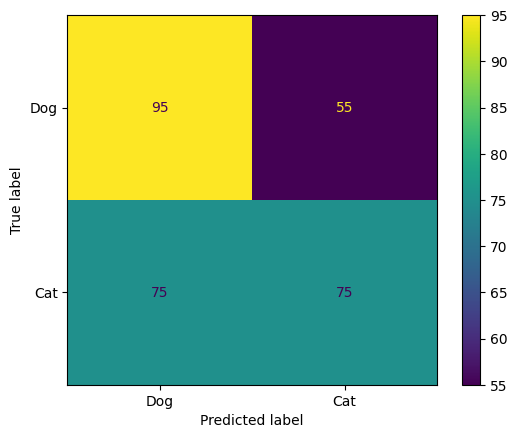

In [82]:
precision = accuracy_score(y_test, pred)
reporte = classification_report(y_test, pred, target_names=Categories)

print("Precision:", precision)
print("\nClassification Report:\n", reporte)

ConfusionMatrixDisplay.from_predictions(y_test, pred, display_labels=Categories)

### Cambiar hiperparámetros

In [90]:
param_grid = {
    "C": [0.1, 1, 10, 100],
    "kernel": ["linear", "rbf", "poly"],
    "gamma": ["scale", 0.1, 0.01, 0.001]
}

grid = GridSearchCV(SVC(), param_grid, cv=5, scoring="accuracy")
grid.fit(X_train, y_train)

print(f"Mejores hiperparámetros: {grid.best_params_} con precisión: {grid.best_score_}")

Mejores hiperparámetros: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'} con precisión: 0.6042857142857143


In [91]:
mejor_modelo = grid.best_estimator_

y_pred_mejor = mejor_modelo.predict(X_test)

precision_mejor = accuracy_score(y_test, y_pred_mejor)
reporte_mejor = classification_report(y_test, y_pred_mejor, target_names=Categories)
print("Precision del mejor modelo:", precision_mejor)
print("\nClassification Report del mejor modelo:\n", reporte_mejor)

Precision del mejor modelo: 0.5933333333333334

Classification Report del mejor modelo:
               precision    recall  f1-score   support

         Dog       0.58      0.66      0.62       150
         Cat       0.61      0.53      0.56       150

    accuracy                           0.59       300
   macro avg       0.60      0.59      0.59       300
weighted avg       0.60      0.59      0.59       300



(np.float64(-0.5), np.float64(299.5), np.float64(198.5), np.float64(-0.5))

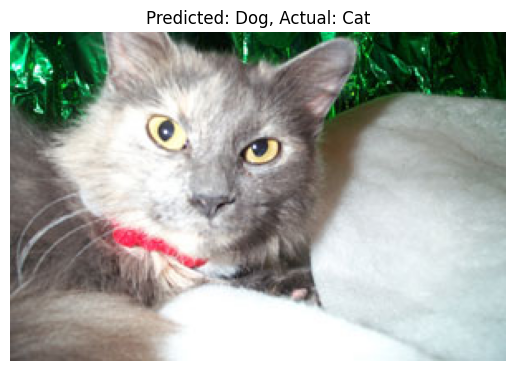

In [94]:
category = random.choice(Categories)
folder = os.path.join(datadir, category)
img_name = random.choice(os.listdir(folder))
img_path = os.path.join(folder, img_name)
img = imread(img_path)
if len(img.shape) == 2:
    img = np.stack((img,) * 3, axis=-1)
if img.shape[2] == 4:
    img = img[:, :, :3]
img_resized = resize(img, (64, 64))
img_flat = img_resized.flatten().reshape(1, -1)
prediction = mejor_modelo.predict(img_flat)[0]
plt.imshow(img)
plt.title(f"Predicted: {Categories[prediction]}, Actual: {category}")
plt.axis("off")

## <span style="color:yellow">Bosques Aleatorios</span>

### Separa X, y, entrenamiento y pruebas

In [97]:
X_rf = df.drop(columns=["Target"]).copy()
y_rf = df["Target"].copy()

In [98]:
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(X_rf, y_rf, test_size=0.3, random_state=28, stratify=y_rf)

### Entrenar modelo y predicciones

In [99]:
rf_model = RandomForestClassifier(random_state=28)
rf_model.fit(X_train_rf, y_train_rf)

RandomForestClassifier(random_state=28)

In [100]:
pred_rf = rf_model.predict(X_test_rf)

### Validaciones

Precision del Random Forest: 0.5766666666666667

Classification Report del Random Forest:
               precision    recall  f1-score   support

         Dog       0.58      0.59      0.58       150
         Cat       0.58      0.57      0.57       150

    accuracy                           0.58       300
   macro avg       0.58      0.58      0.58       300
weighted avg       0.58      0.58      0.58       300



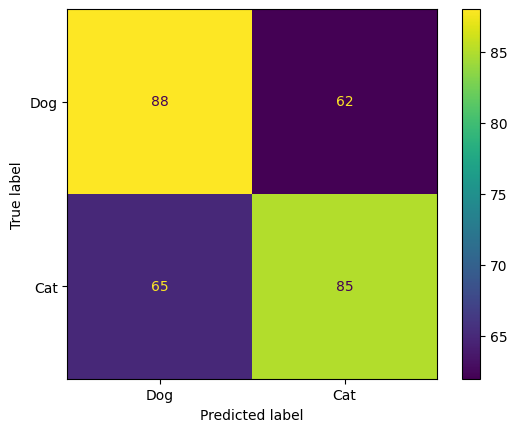

In [101]:
precision_rf = accuracy_score(y_test_rf, pred_rf)
reporte_rf = classification_report(y_test_rf, pred_rf, target_names=Categories)

print("Precision del Random Forest:", precision_rf)
print("\nClassification Report del Random Forest:\n", reporte_rf)
ConfusionMatrixDisplay.from_predictions(y_test_rf, pred_rf, display_labels=Categories)

### Cambiar hiperparametros

In [ ]:
param_grid_rf = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 4, 6],
    "min_samples_leaf": [1, 2, 3],
    "max_features": ["sqrt", "log2", None]
}

grid_rf = GridSearchCV(RandomForestClassifier(random_state=28), param_grid_rf, cv=5, scoring="accuracy", n_jobs=-1)
grid_rf.fit(X_train_rf, y_train_rf)

print(f"Mejores hiperparámetros para Random Forest: {grid_rf.best_params_} con precisión: {grid_rf.best_score_}")

## <span style="color:red">Conclusiones</span>

<p>De lo obsevado podemos inferir lo siguiente:</p>

<ul>
    <li>
        Usando el modelo <strong>Maquinas de Soporte Vectorial</strong> dejado por el profesor se obtuvo una precisión de ~56%, lo cual es bastante baja, practicamente solo la mitad de las imágenes están siendo clasificadas correctamente, esto puede sugerir que el modelo puede no ser el adecuado para este tipo de datos, ya que cada imagen se convierte a un vector de números haciendo que se tengan demasiados features por imagen y este modelo no trata muy bien esta cantidad.
    </li>
    <li>
        Se utilizó GridSearchCV para buscar los mejores hiperparametros para el modelo <strong>Maquinas de Soporte Vectorial</strong>, y se encontró que los mejores fueron C = "10", gamma = "scale" y kernel = "rbf", para obtener una precisión de ~60% lo cual no es una mejora significativa respecto al modelo en su forma predeterminada. El entrenamiento de este modelo demora bastante usando incluso solo una pequeña parte del dataset completo y redimensionando imagenes a un tamaño de 64x64; si la dimensión se deja más grande y se le entrega un dataset más grande podría mejorar su precisión pero también requeriría de una máquina más potente.
    </li>
    <li>
        Incluso al intentar predecir imagenes aleatorias del dataset, con el mejor modelo de <strong>Maquinas de Soporte Vectorial</strong> que obtuvimos, que cuenta con una precisión de ~59%, se registran constantemente errores en la predicción y casi la mitad de intentos se predicen mal.
    </li>
    <li>
        Para el modelo <strong>Maquinas de Soporte Vectorial</strong> es recomendado escalar los datos para tener un mejor rendimiento, pero cuando se aplicó en este ejercicio no se notó una diferencia importante.
    </li>
</ul>